# Fine-Tuned Sentiment Model - Results and Diagnostics

This notebook documents the current production sentiment model and explains why it replaced the original base FinBERT-PT-BR output. The goal is to evaluate both predictive quality and downstream usefulness: the model should improve F1, reduce the base model's excessive NEGATIVE tendency, and still produce economically interpretable weekly sentiment patterns.

The production model is a domain-adapted version of FinBERT-PT-BR trained on the reviewed labeled examples in `labeled_samples/labeled_samples.csv`. The final strategy was selected after a small hyperparameter and seed search. The winning setup uses label-smoothed cross-entropy (`label_smoothing=0.10`), learning rate `1e-5`, weight decay `0.03`, four training epochs and no frozen transformer layers. To reduce variance, the final prediction uses an ensemble of three independently trained seeds (`789`, `123`, `456`). At inference time, the three models produce logits for each class, those logits are averaged, and the final label is chosen by direct argmax. There are no manual thresholds or post-hoc label rules in the final decision.

This strategy matters because the base model was structurally too pessimistic for this corpus: it assigned NEGATIVE to many factual or ambiguous financial-news items. The fine-tuned model keeps sensitivity to genuinely negative events, but gives more room to NEUTRAL and POSITIVE predictions. On the fixed holdout, macro F1 rises from about **0.33** for the base model to about **0.73** for the fine-tuned ensemble.

### Flow
1. Load and prepare the base and fine-tuned outputs.
2. Compare holdout macro F1, holdout F1 by class and full-corpus label transitions.
3. Inspect label distribution, source behavior and weekly dynamics.
4. Review annual extremes and the sentiment heatmap.
5. Summarize why the fine-tuned ensemble is the preferred production signal.


## 1. Setup

This section loads the plotting stack and defines the derived fields used throughout the notebook. Each article receives normalized class probabilities, a prediction confidence score, entropy and a probability-weighted sentiment score `P(POSITIVE) - P(NEGATIVE)`. These fields allow the analysis to compare not only which label was selected, but also how strongly the model supported that prediction.


In [1]:
import calendar
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D
from scipy import stats
from scipy.stats import entropy as scipy_entropy

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

BASE_RESULTS_PATH = PROJECT_ROOT / "output/base_model_classified.jsonl"
FINETUNED_RESULTS_PATH = PROJECT_ROOT / "output/finetuned_model_classified.jsonl"
COLORS = {"POSITIVE": "#27AE60", "NEGATIVE": "#E74C3C", "NEUTRAL": "#3498DB"}
MONTH_ABBR = [calendar.month_abbr[m] for m in range(1, 13)]
DAY_ABBR = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]


def week_key_to_date(wk: str) -> pd.Timestamp:
    """Convert an ISO week key (e.g. '2020-W11') to the Monday of that week."""
    year, week = wk.split("-W")
    return pd.Timestamp.fromisocalendar(int(year), int(week), 1)


def prepare_sentiment_frame(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()

    score_sum = frame["score_positive"] + frame["score_negative"] + frame["score_neutral"]
    frame["pos"] = frame["score_positive"] / score_sum
    frame["neg"] = frame["score_negative"] / score_sum
    frame["neu"] = frame["score_neutral"] / score_sum

    def get_confidence(row):
        return {"POSITIVE": row["pos"], "NEGATIVE": row["neg"], "NEUTRAL": row["neu"]}[
            row["predicted_label"]
        ]

    frame["confidence"] = frame.apply(get_confidence, axis=1)
    frame["net_score"] = frame["pos"] - frame["neg"]
    frame["year"] = frame["week_key"].str[:4].astype(int)
    frame.loc[frame["year"] == 2026, "year"] = 2025

    scores = frame[["pos", "neg", "neu"]].values
    frame["entropy"] = [scipy_entropy(row) for row in scores]

    return frame

## 2. Data Loading

The notebook reads the latest outputs from `output/base_model_classified.jsonl` and `output/finetuned_model_classified.jsonl`. Both files cover the same article universe, which makes the comparison article-by-article rather than comparing two different corpora. The fine-tuned file should be the refreshed production output generated after the latest training run.


In [2]:
df_base_raw = pd.read_json(BASE_RESULTS_PATH, lines=True)
df_finetuned_raw = pd.read_json(FINETUNED_RESULTS_PATH, lines=True)

df_base = prepare_sentiment_frame(df_base_raw)
df_finetuned = prepare_sentiment_frame(df_finetuned_raw)

for _df in [df_base, df_finetuned]:
    _df["published_at"] = pd.to_datetime(_df["published_at"], format="ISO8601", utc=True)
    _df["month"] = _df["published_at"].dt.month
    _df["dayofweek"] = _df["published_at"].dt.dayofweek  # 0=Mon … 6=Sun
    _df["week_num"] = _df["week_key"].str.extract(r"W(\d+)").astype(int)
    _df["week_start"] = _df["week_key"].map(week_key_to_date)

df_base = df_base[df_base["year"].between(2016, 2025)].copy()
df_finetuned = df_finetuned[df_finetuned["year"].between(2016, 2025)].copy()
df = df_finetuned.copy()  # main analysis dataframe (fine-tuned model)

print(f"Base model  — {len(df_base):,} articles  ·  {df_base['published_at'].min().date()} → {df_base['published_at'].max().date()}")
print(f"Fine-tuned  — {len(df_finetuned):,} articles  ·  {df_finetuned['published_at'].min().date()} → {df_finetuned['published_at'].max().date()}")
print(f"Sources: {', '.join(sorted(df['source'].unique()))}")
print()
print(df[["source", "published_at", "predicted_label", "confidence", "net_score", "entropy"]].head(5).to_string())


Base model  — 56,498 articles  ·  2016-01-04 → 2025-12-31
Fine-tuned  — 56,498 articles  ·  2016-01-04 → 2025-12-31
Sources: Exame, InfoMoney, Valor Econômico

            source              published_at predicted_label  confidence  net_score   entropy
0  Valor Econômico 2016-01-04 17:24:13+00:00        NEGATIVE    0.870722  -0.784051  0.466958
1  Valor Econômico 2016-01-04 09:00:01+00:00         NEUTRAL    0.857500  -0.023152  0.506360
2        InfoMoney 2016-01-04 10:04:00+00:00        POSITIVE    0.367486   0.023143  1.093532
3        InfoMoney 2016-01-04 11:55:00+00:00        NEGATIVE    0.920092  -0.875316  0.333349
4  Valor Econômico 2016-01-04 13:45:25+00:00         NEUTRAL    0.711611  -0.045291  0.797027


## 3. Model Quality: F1 and Bias Correction

This section evaluates the final model on the same fixed holdout used during training: a stratified 20% split with seed `2026`. The first chart compares holdout macro F1 for the base and fine-tuned models. The second chart breaks that same holdout down by class, so POSITIVE, NEGATIVE and NEUTRAL are evaluated on the same final test slice.

The lower charts connect the metric gain to corpus-level behavior. The full-corpus distribution shows how the fine-tuned model changes the label mix, and the transition matrix shows where base-model predictions moved after fine-tuning. This is where the negative-bias correction becomes visible: the base model overuses NEGATIVE, while the fine-tuned model reallocates part of that mass toward NEUTRAL and POSITIVE without erasing genuinely negative cases.


Holdout examples: 125
Prediction changes on full corpus: 24.2%
Negative share delta: -13.37 pp
Neutral share delta: +14.38 pp


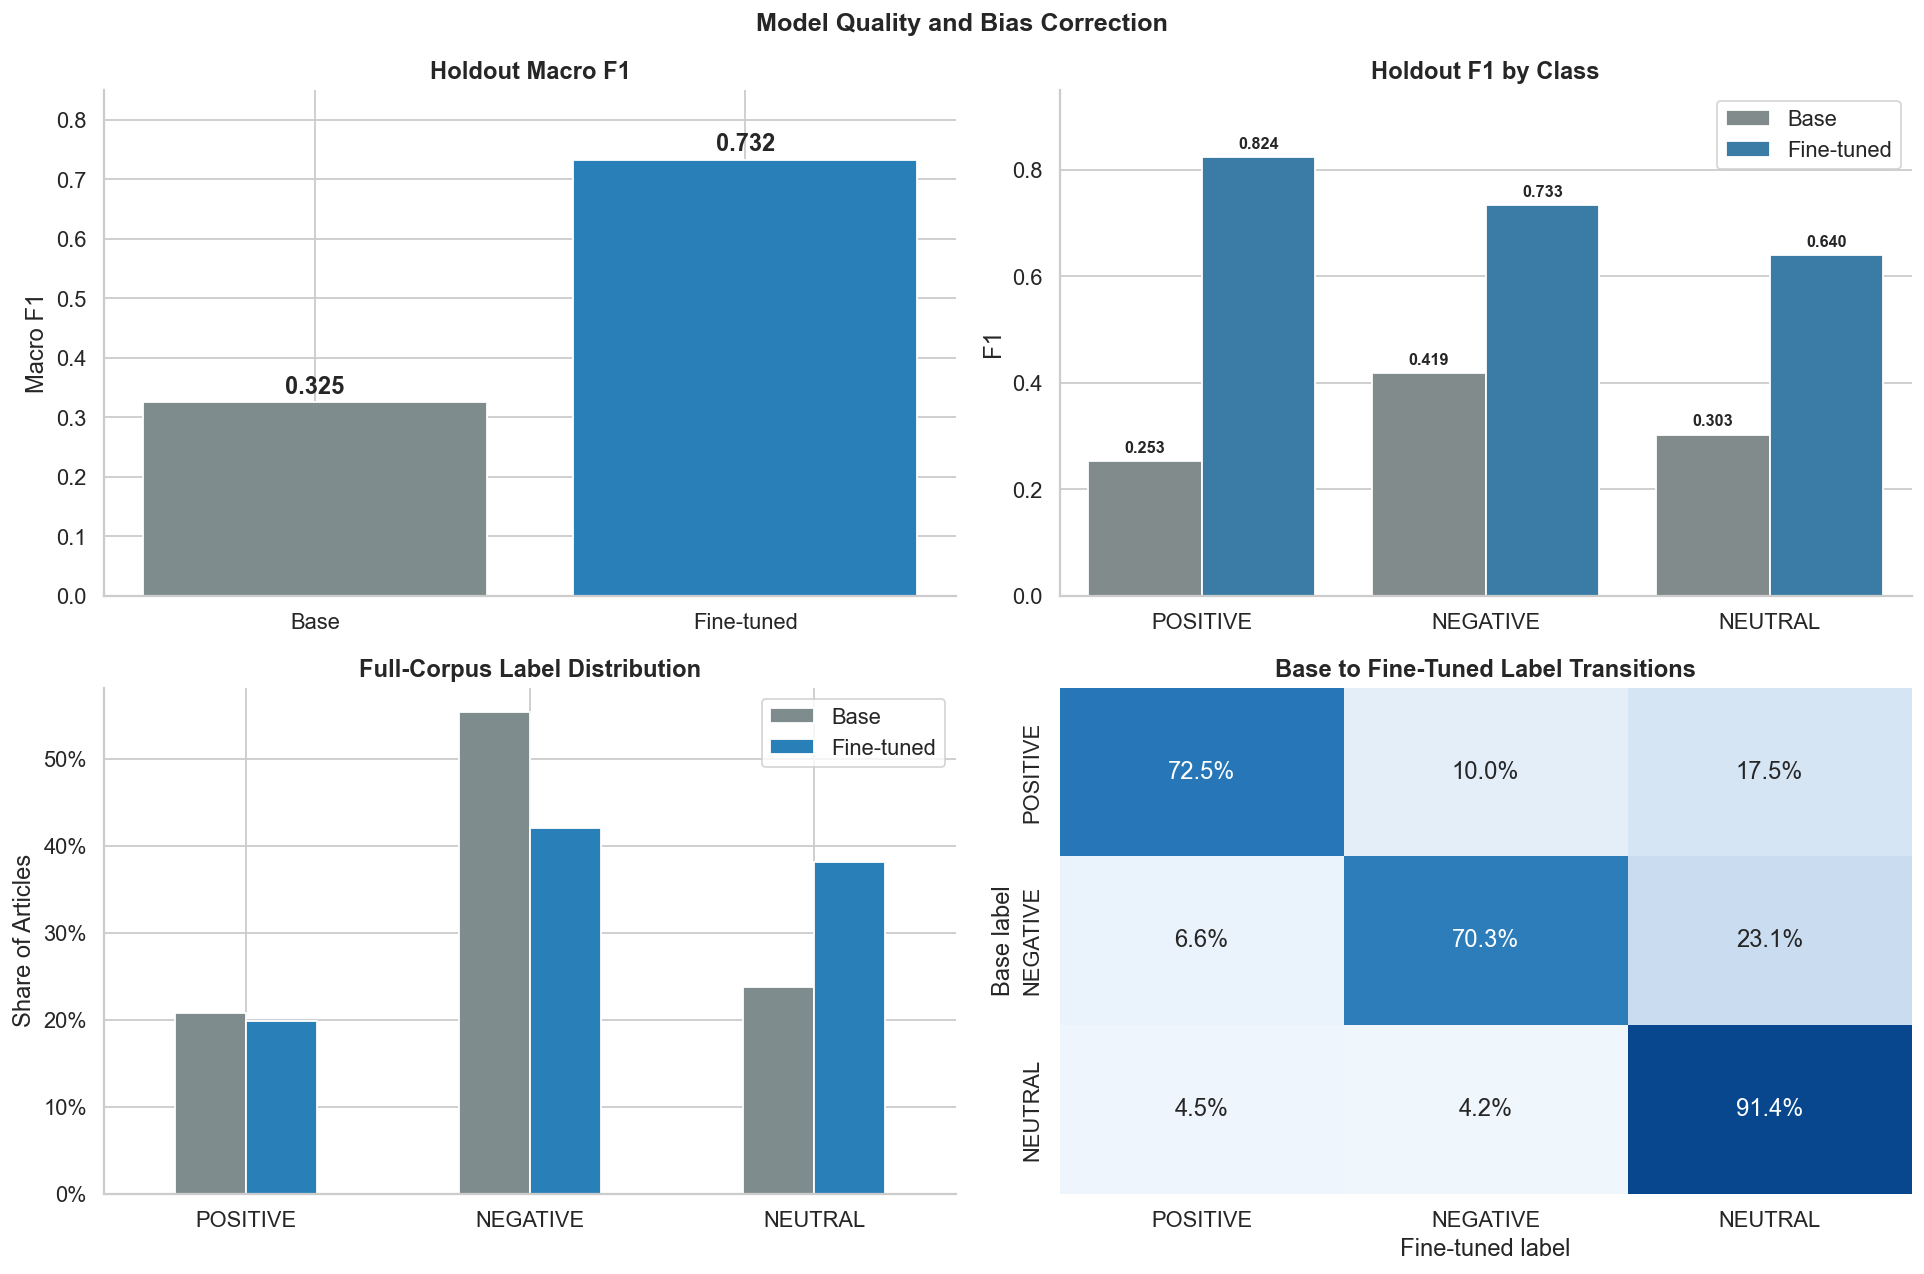

In [3]:
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import json

TRAINING_METADATA_PATH = PROJECT_ROOT / "models/finbert-pt-br-finetuned/training_strategy.json"
LABELED_SAMPLES_PATH = PROJECT_ROOT / "labeled_samples/labeled_samples.csv"
BASE_EVAL_PATH = PROJECT_ROOT / "labeled_samples/labeled_base_model_eval.csv"
FINETUNED_EVAL_PATH = PROJECT_ROOT / "labeled_samples/labeled_finetuned_model_eval.csv"
label_order = ["POSITIVE", "NEGATIVE", "NEUTRAL"]

training_metadata = json.loads(TRAINING_METADATA_PATH.read_text(encoding="utf-8"))
holdout_metrics = training_metadata["holdout_metrics"]

labeled_samples = pd.read_csv(LABELED_SAMPLES_PATH)
labeled_samples = labeled_samples[labeled_samples["human_label"].notna()].copy()
labeled_samples["human_label"] = labeled_samples["human_label"].str.strip().str.upper()
_, holdout_ids = train_test_split(
    labeled_samples[["id", "human_label"]],
    test_size=0.2,
    random_state=2026,
    shuffle=True,
    stratify=labeled_samples["human_label"],
)
holdout_ids = holdout_ids[["id", "human_label"]].reset_index(drop=True)

base_eval = pd.read_csv(BASE_EVAL_PATH)
ft_eval = pd.read_csv(FINETUNED_EVAL_PATH)
holdout_eval = (
    holdout_ids
    .merge(base_eval[["id", "predicted_label"]], on="id", how="left", validate="one_to_one")
    .merge(ft_eval[["id", "ft_predicted_label"]], on="id", how="left", validate="one_to_one")
)


def class_f1_table(frame, prediction_col, model_name):
    report = classification_report(
        frame["human_label"],
        frame[prediction_col],
        labels=label_order,
        output_dict=True,
        zero_division=0,
    )
    return pd.DataFrame([
        {"model": model_name, "class": label, "f1": report[label]["f1-score"]}
        for label in label_order
    ])

metrics_summary = pd.DataFrame([
    {"model": "Base", "macro_f1": holdout_metrics["base_macro_f1"]},
    {"model": "Fine-tuned", "macro_f1": holdout_metrics["finetuned_macro_f1"]},
])
class_f1 = pd.concat([
    class_f1_table(holdout_eval, "predicted_label", "Base"),
    class_f1_table(holdout_eval, "ft_predicted_label", "Fine-tuned"),
], ignore_index=True)

comparison = (
    df_base[["url", "source", "week_key", "published_at", "predicted_label", "confidence", "net_score", "pos", "neg", "neu"]]
    .merge(
        df_finetuned[["url", "predicted_label", "confidence", "net_score", "pos", "neg", "neu"]],
        on="url",
        suffixes=("_base", "_ft"),
        how="inner",
        validate="one_to_one",
    )
)
comparison["label_changed"] = comparison["predicted_label_base"] != comparison["predicted_label_ft"]
comparison["confidence_delta"] = comparison["confidence_ft"] - comparison["confidence_base"]
comparison["net_score_delta"] = comparison["net_score_ft"] - comparison["net_score_base"]
comparison["year"] = comparison["week_key"].str[:4].astype(int)
comparison.loc[comparison["year"] == 2026, "year"] = 2025
comparison = comparison[comparison["year"].between(2016, 2025)].copy()

label_share_comparison = pd.DataFrame({
    "Base": df_base["predicted_label"].value_counts(normalize=True).reindex(label_order, fill_value=0),
    "Fine-tuned": df_finetuned["predicted_label"].value_counts(normalize=True).reindex(label_order, fill_value=0),
})
label_share_comparison["delta_pp"] = (label_share_comparison["Fine-tuned"] - label_share_comparison["Base"]) * 100

transition = pd.crosstab(
    comparison["predicted_label_base"],
    comparison["predicted_label_ft"],
    normalize="index",
).reindex(index=label_order, columns=label_order, fill_value=0)

yearly_compare = (
    comparison.groupby("year")
    .agg(
        n_news=("url", "count"),
        pct_positive_base=("predicted_label_base", lambda x: (x == "POSITIVE").mean()),
        pct_negative_base=("predicted_label_base", lambda x: (x == "NEGATIVE").mean()),
        pct_positive_ft=("predicted_label_ft", lambda x: (x == "POSITIVE").mean()),
        pct_negative_ft=("predicted_label_ft", lambda x: (x == "NEGATIVE").mean()),
        changed_share=("label_changed", "mean"),
        mean_conf_base=("confidence_base", "mean"),
        mean_conf_ft=("confidence_ft", "mean"),
    )
    .reset_index()
    .sort_values("year")
)
yearly_compare["net_label_base"] = yearly_compare["pct_positive_base"] - yearly_compare["pct_negative_base"]
yearly_compare["net_label_ft"] = yearly_compare["pct_positive_ft"] - yearly_compare["pct_negative_ft"]

print(f"Holdout examples: {len(holdout_eval)}")
print(f"Prediction changes on full corpus: {comparison['label_changed'].mean():.1%}")
print(f"Negative share delta: {label_share_comparison.loc['NEGATIVE', 'delta_pp']:+.2f} pp")
print(f"Neutral share delta: {label_share_comparison.loc['NEUTRAL', 'delta_pp']:+.2f} pp")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

ax = axes[0, 0]
bars = ax.bar(metrics_summary["model"], metrics_summary["macro_f1"], color=["#7F8C8D", "#2980B9"])
for bar, value in zip(bars, metrics_summary["macro_f1"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.015, f"{value:.3f}", ha="center", fontweight="bold")
ax.set_ylim(0, 0.85)
ax.set_title("Holdout Macro F1", fontweight="bold")
ax.set_ylabel("Macro F1")

ax = axes[0, 1]
sns.barplot(data=class_f1, x="class", y="f1", hue="model", order=label_order, ax=ax, palette=["#7F8C8D", "#2980B9"])
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9, fontweight="bold")
ax.set_ylim(0, 0.95)
ax.set_title("Holdout F1 by Class", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("F1")
ax.legend(title="")

ax = axes[1, 0]
label_share_comparison[["Base", "Fine-tuned"]].plot(kind="bar", ax=ax, color=["#7F8C8D", "#2980B9"], edgecolor="white")
ax.set_title("Full-Corpus Label Distribution", fontweight="bold")
ax.set_ylabel("Share of Articles")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)

ax = axes[1, 1]
sns.heatmap(transition, annot=True, fmt=".1%", cmap="Blues", vmin=0, vmax=1, ax=ax, cbar=False)
ax.set_title("Base to Fine-Tuned Label Transitions", fontweight="bold")
ax.set_xlabel("Fine-tuned label")
ax.set_ylabel("Base label")

plt.suptitle("Model Quality and Bias Correction", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 4. Label Distribution Overview

This section checks whether the fine-tuned output is plausible at corpus scale. The bar chart shows the final class mix, the confidence histogram shows how strongly the model supports each selected label, and the net-sentiment distribution shows whether article-level scores are centered around a usable range.

The expected behavior is not an equal split across classes. Financial news is naturally cautious, so NEGATIVE can remain large. The important change is that NEUTRAL becomes large enough to absorb routine market updates and factual news that should not be forced into a negative reading.


Predicted label distribution (fine-tuned model):
  NEGATIVE   23,748  ( 42.0%)  █████████████████████
  NEUTRAL    21,553  ( 38.1%)  ███████████████████
  POSITIVE   11,197  ( 19.8%)  █████████


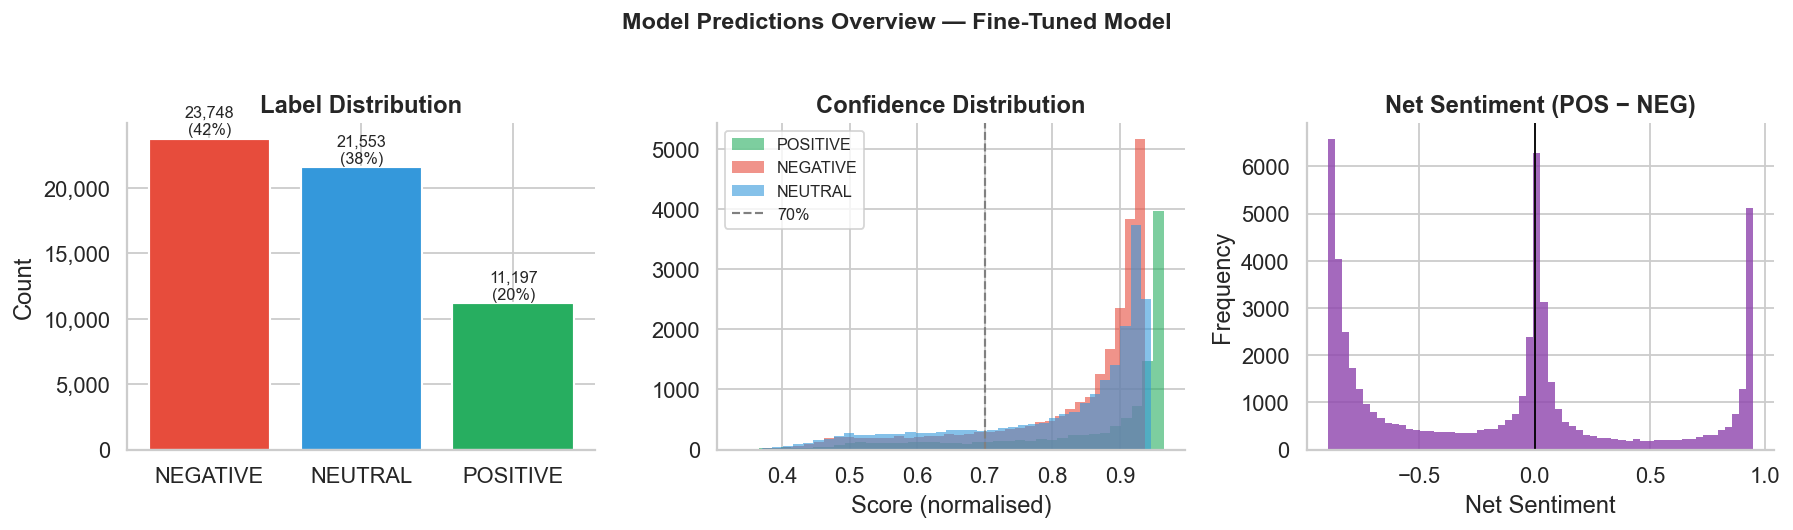

In [4]:
print("Predicted label distribution (fine-tuned model):")
counts = df["predicted_label"].value_counts()
pcts = (counts / len(df) * 100).round(1)
for label, cnt in counts.items():
    bar = "█" * int(pcts[label] / 2)
    print(f"  {label:10s} {cnt:6,}  ({pcts[label]:5.1f}%)  {bar}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
bars = ax.bar(counts.index, counts.values,
              color=[COLORS[label] for label in counts.index], edgecolor="white", linewidth=1.2)
for bar, pct in zip(bars, pcts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 80,
            f"{bar.get_height():,}\n({pct:.0f}%)", ha="center", va="bottom", fontsize=9)
ax.set_title("Label Distribution", fontweight="bold")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax = axes[1]
for label, color in COLORS.items():
    subset = df[df["predicted_label"] == label]["confidence"]
    ax.hist(subset, bins=40, alpha=0.6, label=label, color=color, edgecolor="none")
ax.axvline(0.70, color="gray", linestyle="--", linewidth=1.2, label="70%")
ax.set_title("Confidence Distribution", fontweight="bold")
ax.set_xlabel("Score (normalised)")
ax.legend(fontsize=9)

ax = axes[2]
ax.hist(df["net_score"], bins=60, color="#8E44AD", edgecolor="none", alpha=0.8)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Net Sentiment (POS − NEG)", fontweight="bold")
ax.set_xlabel("Net Sentiment")
ax.set_ylabel("Frequency")

plt.suptitle("Model Predictions Overview — Fine-Tuned Model", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 5. Analysis by News Source

This source-level view checks whether the fine-tuned behavior is consistent across Valor Economico, Exame and InfoMoney. The goal is not to rank sources, but to confirm that the aggregate sentiment pattern is not being driven by a single outlet or by publication volume alone.

The first chart keeps article volume visible by year. The second chart compares each source's overall label composition, which helps identify whether one source is structurally more positive, negative or neutral after fine-tuning.


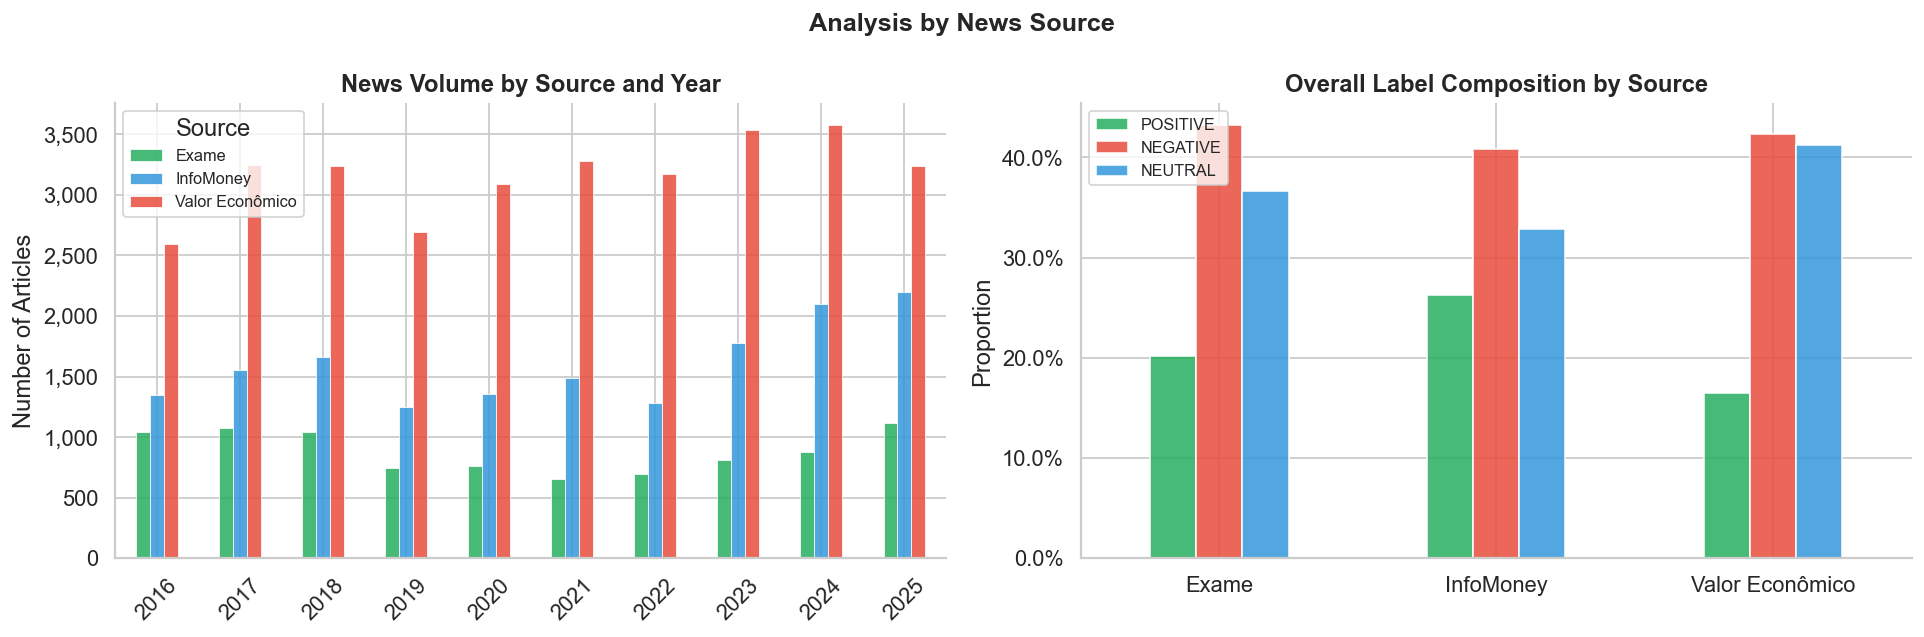

In [5]:
sources = sorted(df["source"].unique())
src_colors = {"Valor Econômico": "#E74C3C", "Exame": "#27AE60", "InfoMoney": "#3498DB"}

source_year = (
    df.groupby(["source", "year"])
.agg(
        n_news=("predicted_label", "count"),
        mean_net=("net_score", "mean"),
        pct_pos=("predicted_label", lambda x: (x == "POSITIVE").mean()),
        pct_neg=("predicted_label", lambda x: (x == "NEGATIVE").mean()),
        pct_neu=("predicted_label", lambda x: (x == "NEUTRAL").mean()),
    )
    .reset_index()
)
source_year["net_label"] = source_year["pct_pos"] - source_year["pct_neg"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
pivot_vol = source_year.pivot(index="year", columns="source", values="n_news").fillna(0)
pivot_vol.plot(
    kind="bar",
    ax=ax,
    color=[src_colors.get(source_name, "#999") for source_name in pivot_vol.columns],
    edgecolor="white",
    linewidth=0.5,
    alpha=0.85,
)
ax.set_title("News Volume by Source and Year", fontweight="bold")
ax.set_ylabel("Number of Articles")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.legend(title="Source", fontsize=9)
ax.set_xlabel("")

ax = axes[1]
src_global = (
    df.groupby("source")["predicted_label"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .reindex(columns=["POSITIVE", "NEGATIVE", "NEUTRAL"], fill_value=0)
)
src_global.plot(
    kind="bar",
    ax=ax,
    color=[COLORS["POSITIVE"], COLORS["NEGATIVE"], COLORS["NEUTRAL"]],
    edgecolor="white",
    alpha=0.85,
)
ax.set_title("Overall Label Composition by Source", fontweight="bold")
ax.set_ylabel("Proportion")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(fontsize=9)
ax.set_xlabel("")

plt.suptitle("Analysis by News Source", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Moving Averages & Time-Series Smoothing

Weekly sentiment is noisy, so this section reads the fine-tuned signal through moving averages. The first chart tracks smoothed class probabilities to show whether POSITIVE, NEGATIVE or NEUTRAL is driving the period. The second chart summarizes the probability-weighted net sentiment through short and medium horizons.

The 13-week moving average is the main trend line for interpretation. It reduces week-to-week volatility while preserving regime changes around crises, policy shifts and recovery periods.


In [6]:
weekly = (
    df.groupby(["week_key", "week_start", "year"])
    .agg(
        n_news       = ("predicted_label", "count"),
        pct_positive = ("pos", "mean"),
        pct_negative = ("neg", "mean"),
        pct_neutral  = ("neu", "mean"),
        net_score    = ("net_score", "mean"),
        confidence   = ("confidence", "mean"),
        n_positive   = ("predicted_label", lambda x: (x == "POSITIVE").sum()),
        n_negative   = ("predicted_label", lambda x: (x == "NEGATIVE").sum()),
        n_neutral    = ("predicted_label", lambda x: (x == "NEUTRAL").sum()),
    )
    .reset_index()
    .sort_values("week_start")
)

weekly["pct_pos_label"] = weekly["n_positive"] / weekly["n_news"]
weekly["pct_neg_label"] = weekly["n_negative"] / weekly["n_news"]
weekly["pct_neu_label"] = weekly["n_neutral"]  / weekly["n_news"]
weekly["net_label"]     = weekly["pct_pos_label"] - weekly["pct_neg_label"]

print(f"Total weeks: {len(weekly)}")
print(f"Mean articles per week: {weekly['n_news'].mean():.1f}  (min: {weekly['n_news'].min()}, max: {weekly['n_news'].max()})")


Total weeks: 522
Mean articles per week: 108.2  (min: 38, max: 201)


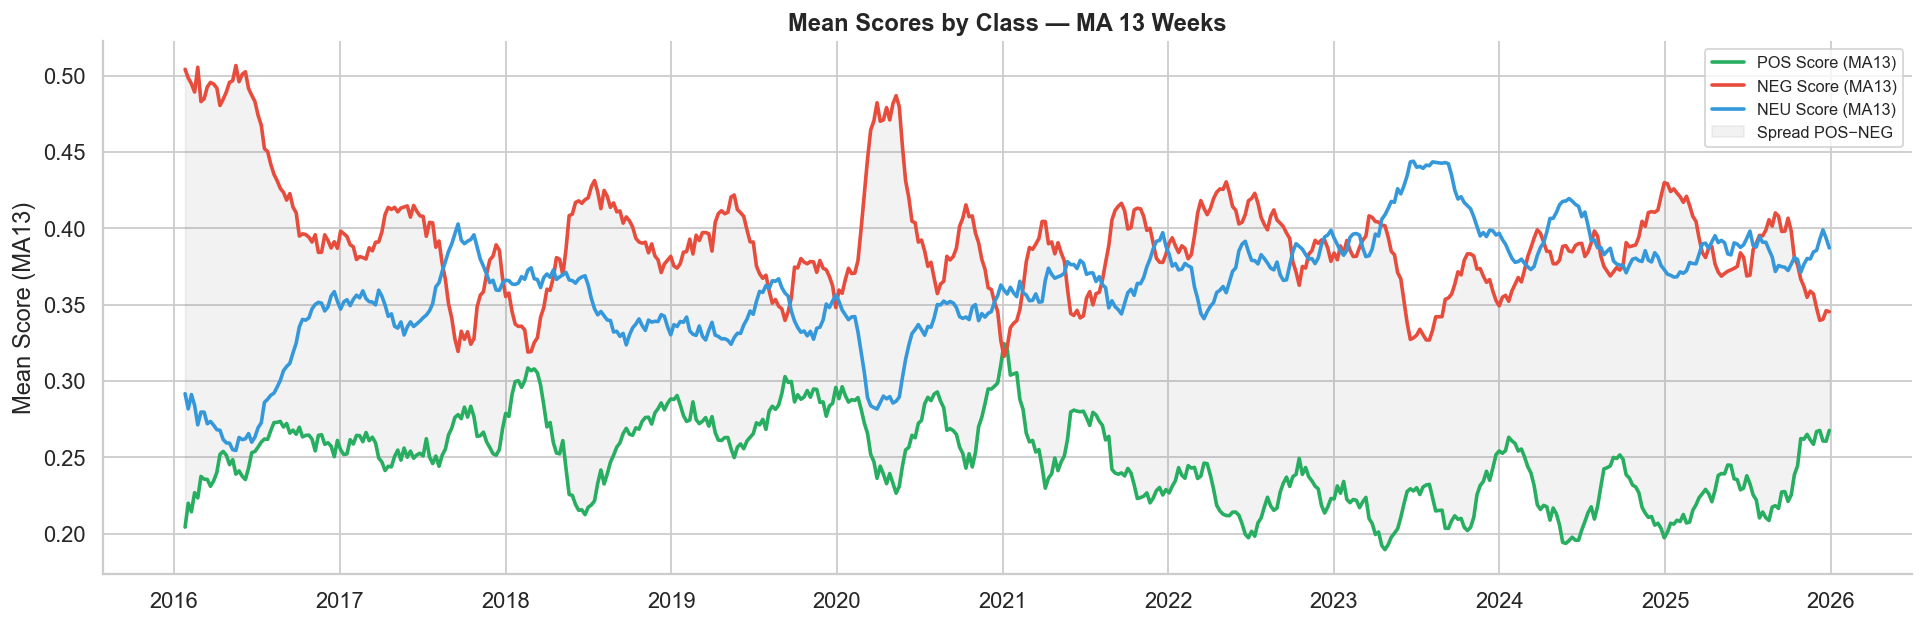

In [7]:
weekly = weekly.sort_values("week_start").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(15, 5))

weekly["ma13_pos"] = weekly["pct_positive"].rolling(13, min_periods=4).mean()
weekly["ma13_neg"] = weekly["pct_negative"].rolling(13, min_periods=4).mean()
weekly["ma13_neu"] = weekly["pct_neutral"].rolling(13, min_periods=4).mean()

ax.plot(weekly["week_start"], weekly["ma13_pos"], color=COLORS["POSITIVE"], linewidth=2, label="POS Score (MA13)")
ax.plot(weekly["week_start"], weekly["ma13_neg"], color=COLORS["NEGATIVE"], linewidth=2, label="NEG Score (MA13)")
ax.plot(weekly["week_start"], weekly["ma13_neu"], color=COLORS["NEUTRAL"],  linewidth=2, label="NEU Score (MA13)")
ax.fill_between(weekly["week_start"], weekly["ma13_pos"], weekly["ma13_neg"],
                alpha=0.10, color="gray", label="Spread POS−NEG")
ax.set_ylabel("Mean Score (MA13)")
ax.set_title("Mean Scores by Class — MA 13 Weeks", fontweight="bold")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.show()


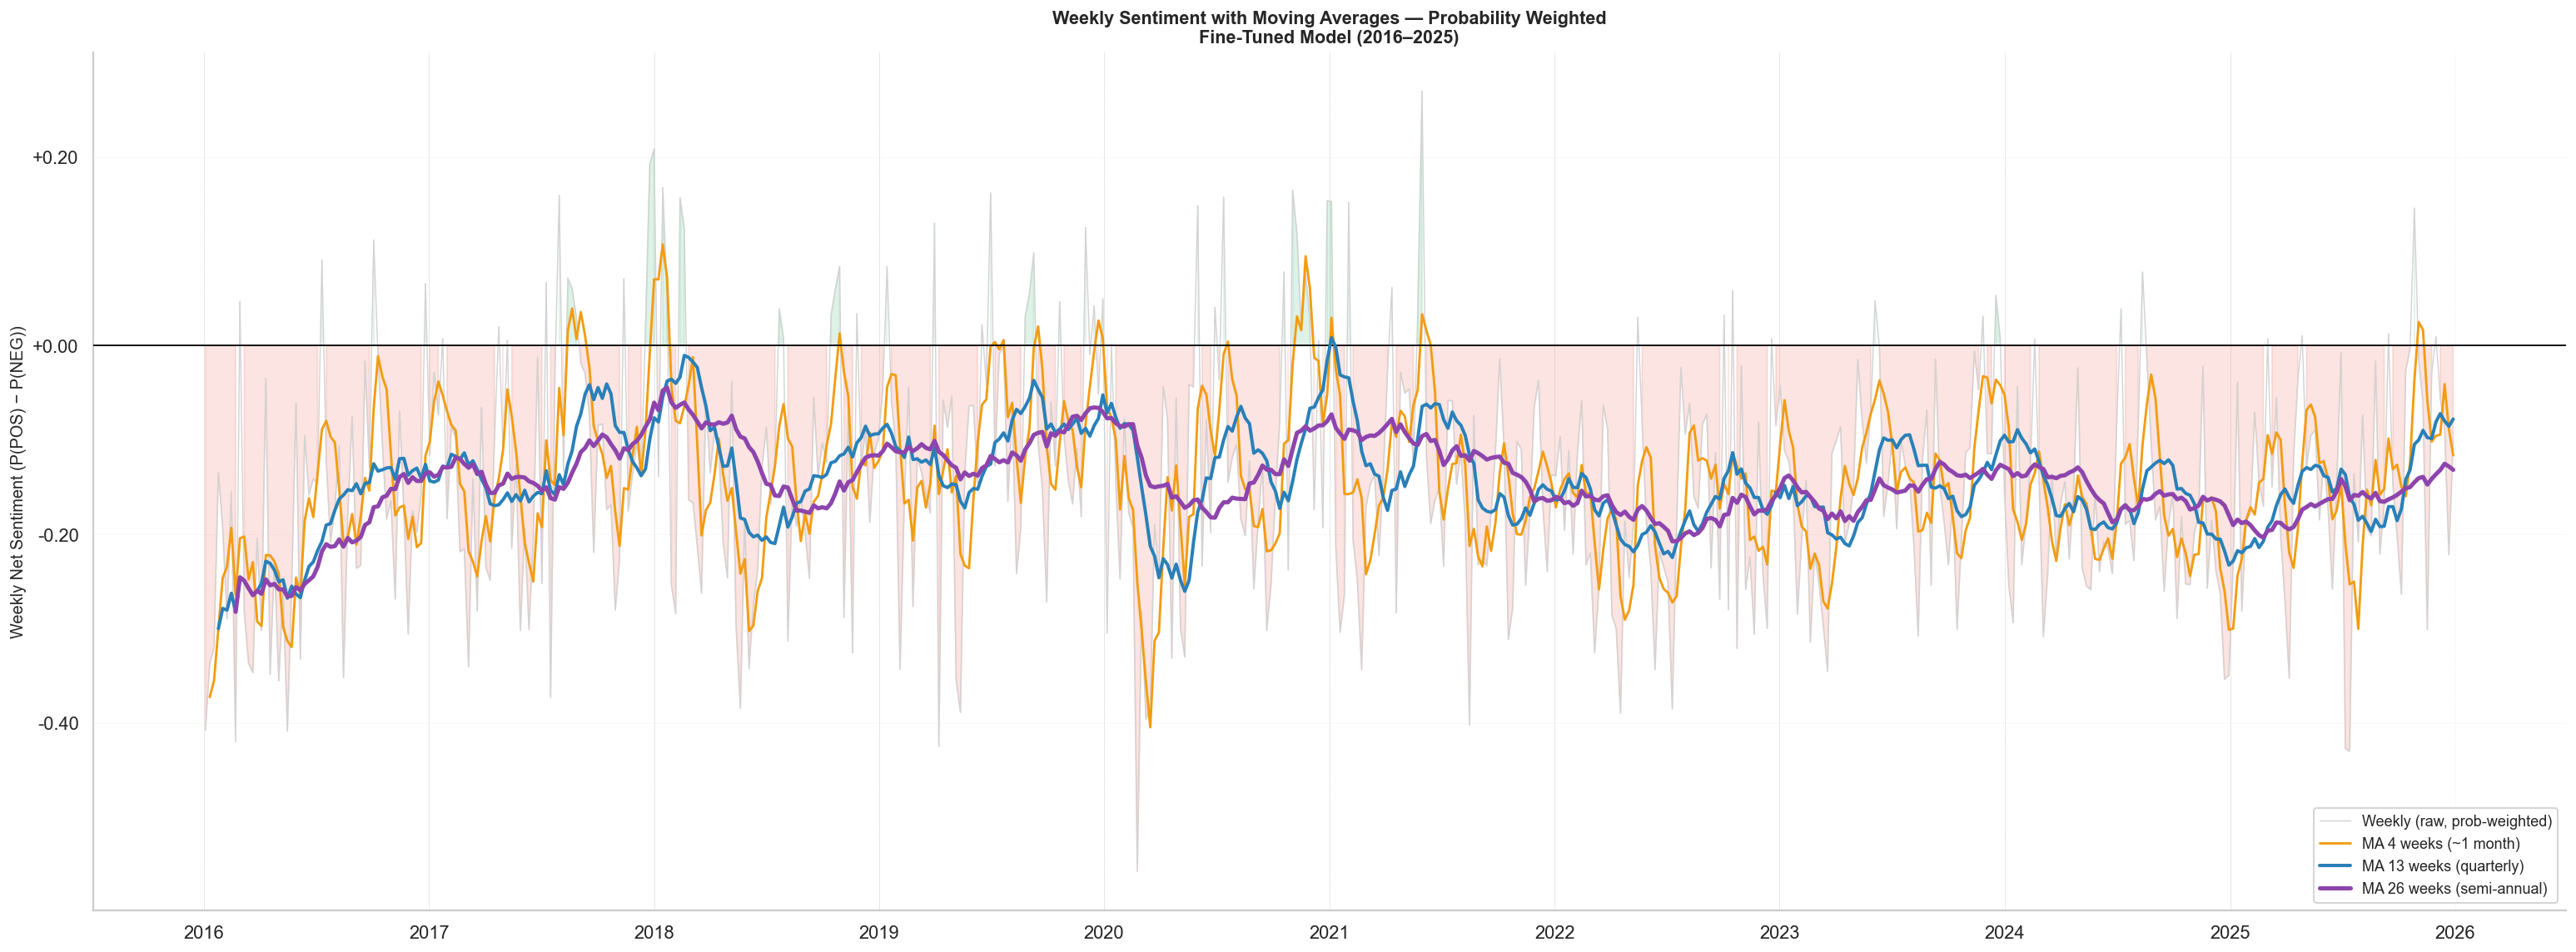

In [8]:
weekly["net_weighted"] = weekly["pct_positive"] - weekly["pct_negative"]

weekly["ma4"]  = weekly["net_weighted"].rolling(4,  min_periods=2).mean()
weekly["ma13"] = weekly["net_weighted"].rolling(13, min_periods=4).mean()
weekly["ma26"] = weekly["net_weighted"].rolling(26, min_periods=8).mean()

fig, ax = plt.subplots(figsize=(24, 9))

net = weekly["net_weighted"].values
ax.fill_between(weekly["week_start"], net, 0,
                where=(net >= 0), color=COLORS["POSITIVE"], alpha=0.15, zorder=1)
ax.fill_between(weekly["week_start"], net, 0,
                where=(net < 0), color=COLORS["NEGATIVE"], alpha=0.15, zorder=1)

ax.plot(weekly["week_start"], weekly["net_weighted"],
        color="lightgray", linewidth=0.8, label="Weekly (raw, prob-weighted)", zorder=2)
ax.plot(weekly["week_start"], weekly["ma4"],
        color="#F39C12", linewidth=1.6, label="MA 4 weeks (~1 month)", zorder=3)
ax.plot(weekly["week_start"], weekly["ma13"],
        color="#2980B9", linewidth=2.2, label="MA 13 weeks (quarterly)", zorder=4)
ax.plot(weekly["week_start"], weekly["ma26"],
        color="#8E44AD", linewidth=2.8, label="MA 26 weeks (semi-annual)", zorder=5)

ax.axhline(0, color="black", linewidth=1.0, zorder=3)

for year in range(2016, 2026):
    ax.axvline(pd.Timestamp(f"{year}-01-01"), color="lightgray",
               linewidth=0.5, alpha=0.5, zorder=0)

ax.set_ylabel("Weekly Net Sentiment (P(POS) − P(NEG))", fontsize=11)
ax.set_title("Weekly Sentiment with Moving Averages — Probability Weighted\n"
             "Fine-Tuned Model (2016–2025)",
             fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.2f}"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(fontsize=10, loc="lower right", framealpha=0.9)
ax.grid(True, alpha=0.2, linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.show()

mu_raw = weekly["net_weighted"].mean()
mu_ma4 = weekly["ma4"].mean()
mu_ma13 = weekly["ma13"].mean()
mu_ma26 = weekly["ma26"].mean()


## 7. Anomaly Detection - Annual Sentiment Extremes

This section keeps one compact anomaly view: for each year, it highlights the most pessimistic and most optimistic weeks. The objective is to validate whether the fine-tuned signal still reacts to recognizable economic events while avoiding the constant negative baseline seen in the base model.

The chart should be read as an event sanity check. Severe shocks should still appear as negative extremes, and recovery or policy-positive windows should appear as positive local peaks.


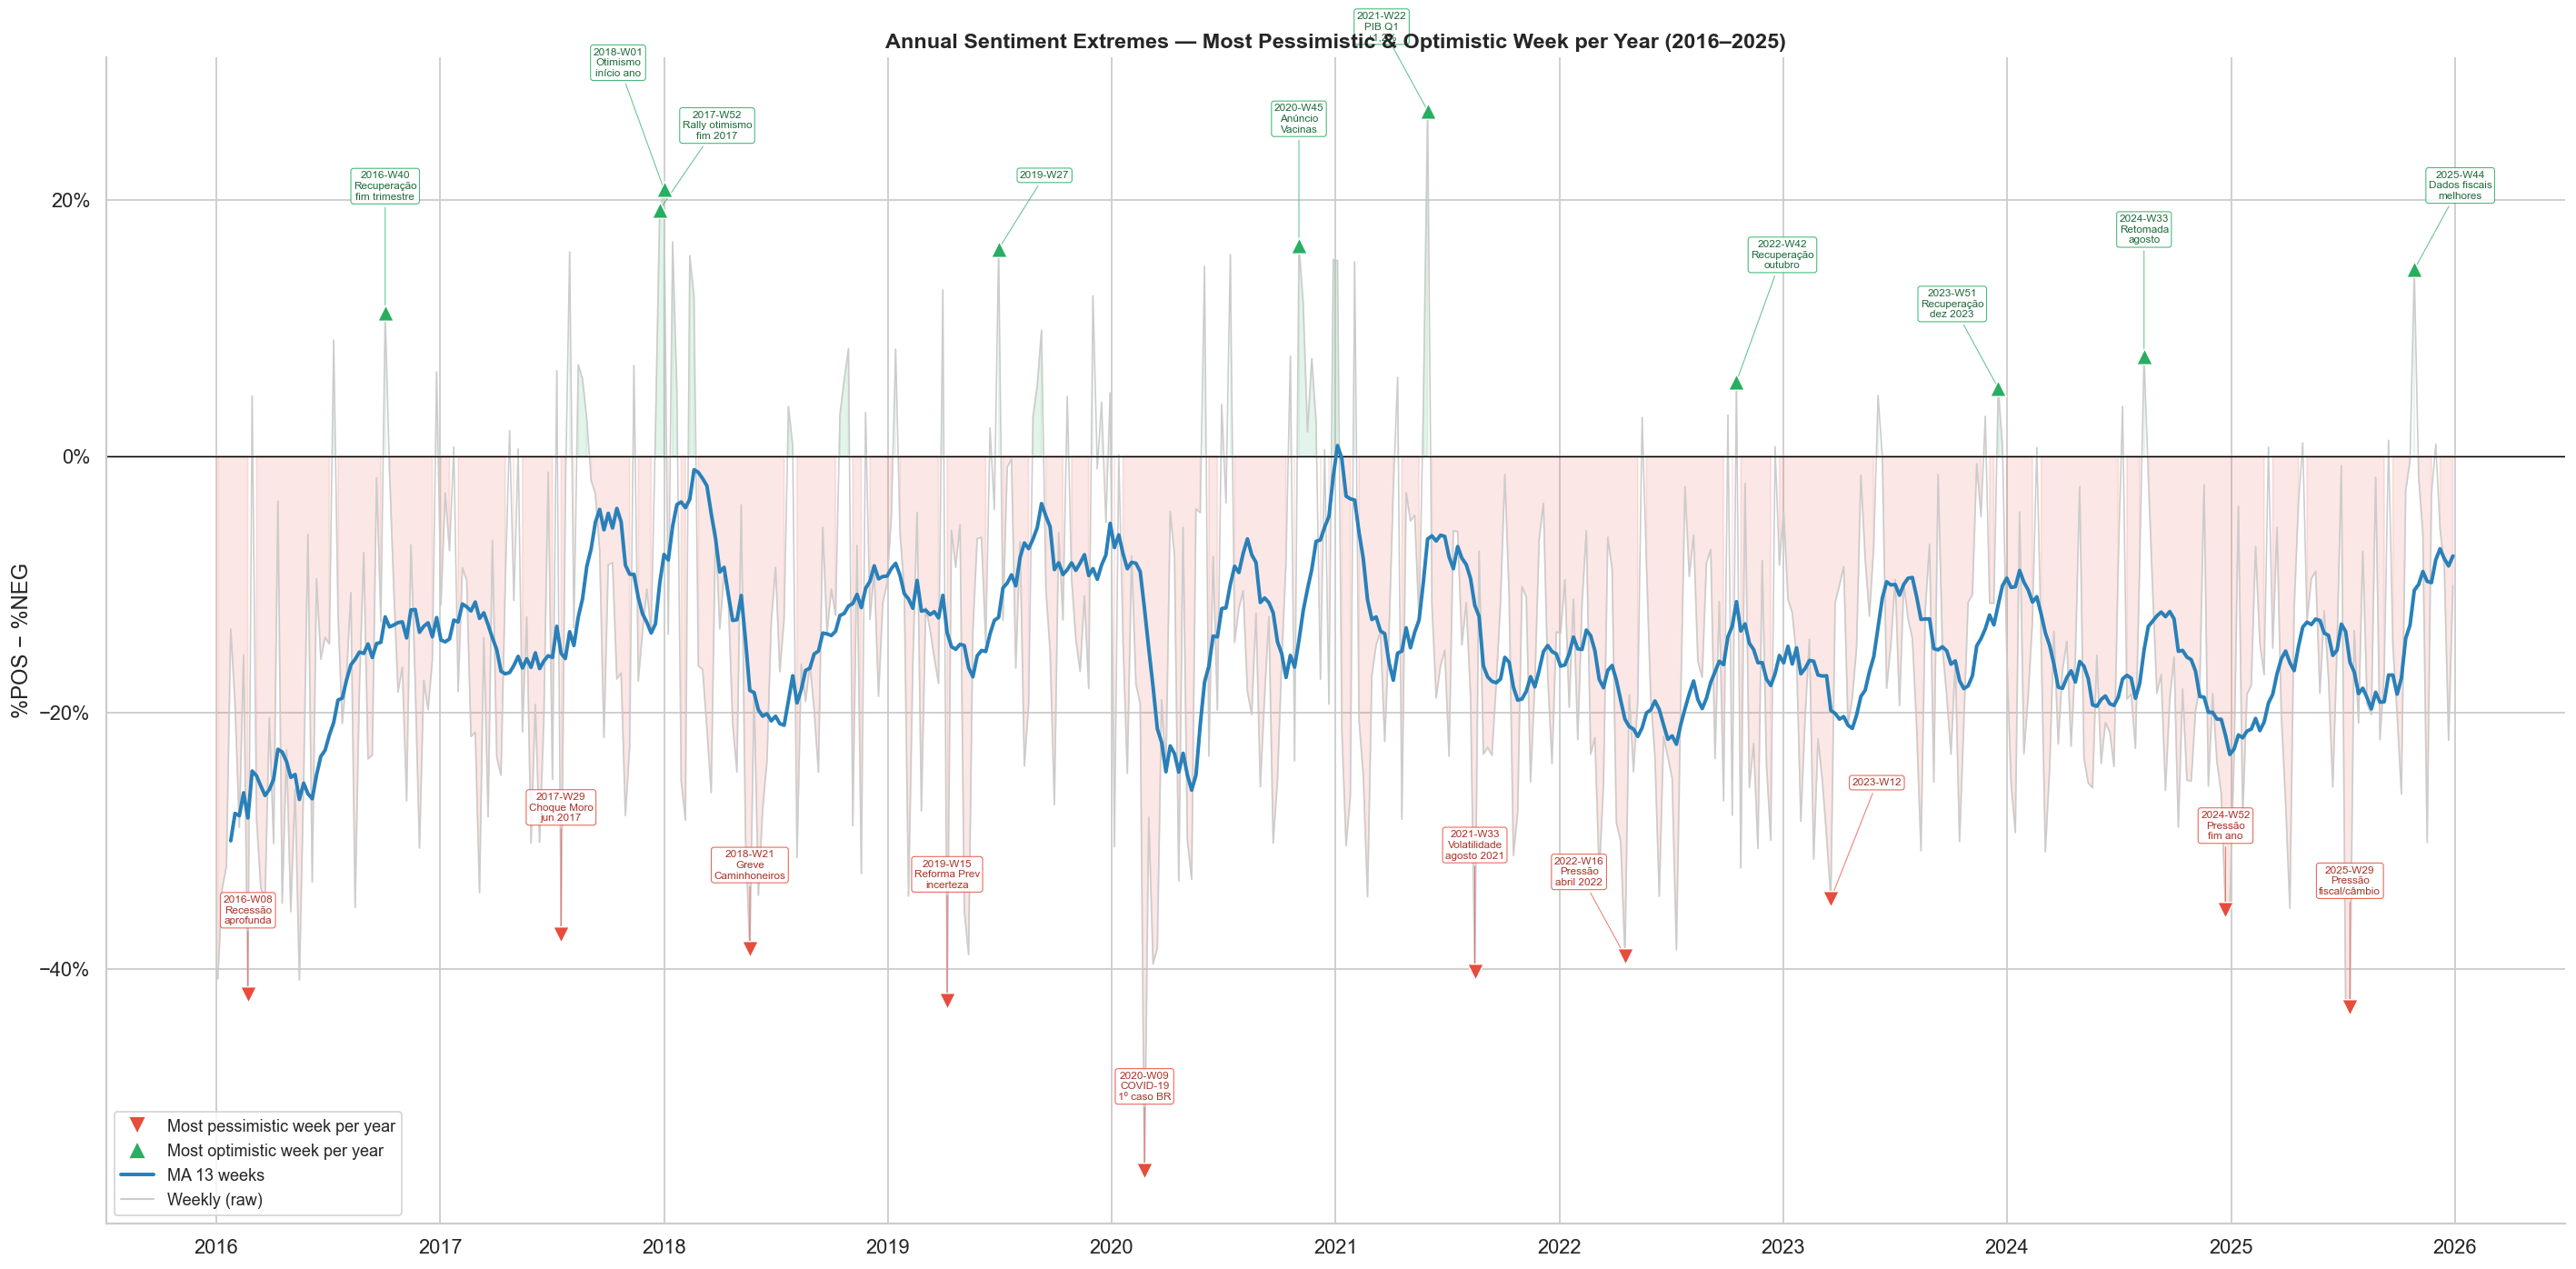

In [9]:
# Compute z-scores for reference
weekly["zscore"] = stats.zscore(weekly["net_weighted"].fillna(0))

# Select min and max week per year (1 pessimistic + 1 optimistic per year)
yearly_extremes = []
for year in sorted(weekly["year"].unique()):
    year_data = weekly[weekly["year"] == year]
    
    # Most pessimistic week in this year
    min_idx = year_data["net_weighted"].idxmin()
    if pd.notna(min_idx):
        yearly_extremes.append(weekly.loc[min_idx])
    
    # Most optimistic week in this year
    max_idx = year_data["net_weighted"].idxmax()
    if pd.notna(max_idx):
        yearly_extremes.append(weekly.loc[max_idx])

# Separate into neg and pos, sorted by time
top_neg = pd.DataFrame(yearly_extremes)
top_neg = top_neg[top_neg["net_weighted"] < 0].sort_values("week_start").reset_index(drop=True)
top_pos = pd.DataFrame(yearly_extremes)
top_pos = top_pos[top_pos["net_weighted"] >= 0].sort_values("week_start").reset_index(drop=True)

# Events that explain the extreme weeks per year (1 min + 1 max per year)
ANOMALY_EVENTS = {
    # 2016: Recessão + recuperação leve
    "2016-W08": "Recessão\naprofunda",
    "2016-W40": "Recuperação\nfim trimestre",
    
    # 2017: Moro + Rally
    "2017-W29": "Choque Moro\njun 2017",
    "2017-W52": "Rally otimismo\nfim 2017",
    
    # 2018: Greve caminhoneiros + Início ano
    "2018-W21": "Greve\nCaminhoneiros",
    "2018-W01": "Otimismo\ninício ano",
    
    # 2019: Reforma incerteza + avanço reforma
    "2019-W15": "Reforma Prev\nincerteza",
    "2019-W14": "Avanço\nReforma Prev",
    
    # 2020: COVID-19 + Vacinas
    "2020-W09": "COVID-19\n1º caso BR",
    "2020-W45": "Anúncio\nVacinas",
    
    # 2021: Volatilidade + PIB crescimento
    "2021-W33": "Volatilidade\nagosto 2021",
    "2021-W22": "PIB Q1\n+1,2%",
    
    # 2022: Pressão pré-eleição + recuperação
    "2022-W16": "Pressão\nabril 2022",
    "2022-W42": "Recuperação\noutubro",
    
    # 2023: Americana + final ano
    "2023-W42": "Volatilidade\noutubro",
    "2023-W51": "Recuperação\ndez 2023",
    
    # 2024: Pressão cambial + retomada
    "2024-W52": "Pressão\nfim ano",
    "2024-W33": "Retomada\nagosto",
    
    # 2025: Pressão fiscal + melhora
    "2025-W29": "Pressão\nfiscal/câmbio",
    "2025-W44": "Dados fiscais\nmelhores",
}

# Staggered offsets for annual extremes (10 neg + 10 pos)
NEG_YOFFS = [42, 68, 42, 68, 42, 68, 42, 68, 42, 68]
NEG_XOFFS = [0,   0,  0,  0,   0,  0, -28, 28,  0,  0]
POS_YOFFS = [68, 42, 68, 42, 68, 42, 68, 42, 68, 42]
POS_XOFFS = [0,  35, -28, 28,  0, -28, 28, -28,  0, 28]

fig, ax = plt.subplots(figsize=(22, 11))

# Background: time series + fill
net = weekly["net_weighted"].values
ax.fill_between(weekly["week_start"], net, 0,
                where=(net >= 0), color=COLORS["POSITIVE"], alpha=0.13, zorder=1)
ax.fill_between(weekly["week_start"], net, 0,
                where=(net  < 0), color=COLORS["NEGATIVE"], alpha=0.13, zorder=1)
ax.plot(weekly["week_start"], weekly["net_weighted"],
        color="#CCCCCC", linewidth=0.9, zorder=2)
ax.plot(weekly["week_start"], weekly["ma13"],
        color="#2980B9", linewidth=2.2, zorder=3)
ax.axhline(0, color="black", linewidth=0.8, zorder=2)

# --- Annotate top-10 negative weeks ---
for i, row in top_neg.iterrows():
    event = ANOMALY_EVENTS.get(row["week_key"], "")
    label_text = f"{row['week_key']}\n{event}" if event else row["week_key"]
    xoff = NEG_XOFFS[i] if i < len(NEG_XOFFS) else 0
    yoff = NEG_YOFFS[i] if i < len(NEG_YOFFS) else 42
    ax.scatter(row["week_start"], row["net_weighted"],
               color=COLORS["NEGATIVE"], s=95, zorder=5,
               marker="v", edgecolors="white", linewidth=0.8)
    ax.annotate(
        label_text,
        xy=(row["week_start"], row["net_weighted"]),
        xytext=(xoff, yoff),
        textcoords="offset points",
        ha="center", va="bottom", fontsize=6.5, color="#A93226",
        arrowprops=dict(arrowstyle="-", color=COLORS["NEGATIVE"], lw=0.6, alpha=0.7),
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=COLORS["NEGATIVE"],
                  alpha=0.85, lw=0.6),
    )

# --- Annotate top-10 positive weeks ---
for i, row in top_pos.iterrows():
    event = ANOMALY_EVENTS.get(row["week_key"], "")
    label_text = f"{row['week_key']}\n{event}" if event else row["week_key"]
    xoff = POS_XOFFS[i] if i < len(POS_XOFFS) else 0
    yoff = POS_YOFFS[i] if i < len(POS_YOFFS) else 42
    ax.scatter(row["week_start"], row["net_weighted"],
               color=COLORS["POSITIVE"], s=95, zorder=5,
               marker="^", edgecolors="white", linewidth=0.8)
    ax.annotate(
        label_text,
        xy=(row["week_start"], row["net_weighted"]),
        xytext=(xoff, yoff),
        textcoords="offset points",
        ha="center", va="bottom", fontsize=6.5, color="#1D6A39",
        arrowprops=dict(arrowstyle="-", color=COLORS["POSITIVE"], lw=0.6, alpha=0.7),
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=COLORS["POSITIVE"],
                  alpha=0.85, lw=0.6),
    )

ax.set_title(
    "Annual Sentiment Extremes — Most Pessimistic & Optimistic Week per Year (2016–2025)",
    fontweight="bold", fontsize=13,
)
ax.set_ylabel("%POS − %NEG")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())

legend_elements = [
    Line2D([0], [0], marker="v", color="w", markerfacecolor=COLORS["NEGATIVE"],
           markersize=11, label="Most pessimistic week per year"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor=COLORS["POSITIVE"],
           markersize=11, label="Most optimistic week per year"),
    Line2D([0], [0], color="#2980B9", linewidth=2.2, label="MA 13 weeks"),
    Line2D([0], [0], color="#CCCCCC", linewidth=1.2, label="Weekly (raw)"),
]
ax.legend(handles=legend_elements, fontsize=10, loc="lower left")

plt.tight_layout()
plt.show()


## 8. Sentiment Heatmap - Week x Year

The heatmap compresses the weekly time series into a year-by-week grid. It is useful for spotting persistent stress regimes, short-lived shocks and recovery windows across the decade.

Compared with the base model, the fine-tuned heatmap is easier to interpret because the negative color bands are less dominated by a structural model bias. Red blocks are therefore closer to actual stress periods rather than a constant background pessimism.


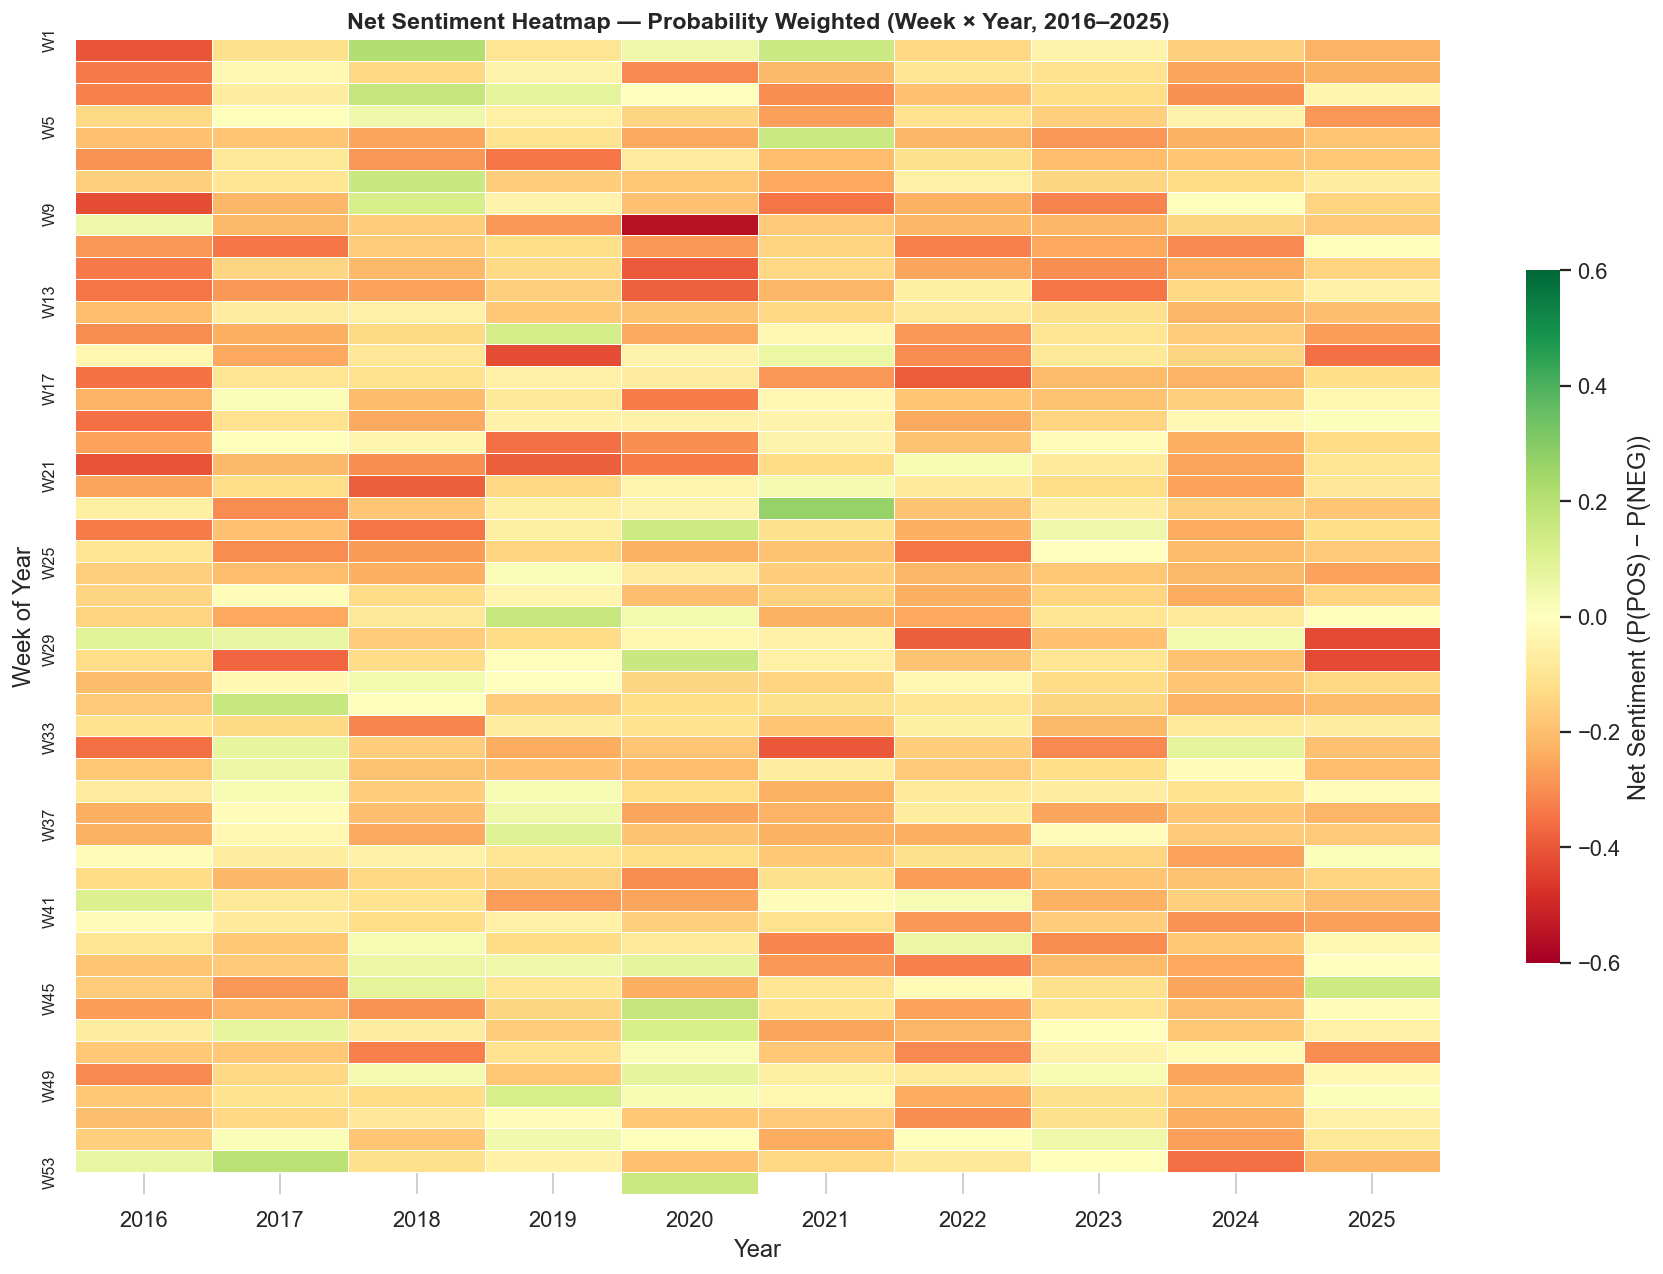

In [10]:
weekly["week_num"] = weekly["week_key"].str.extract(r"W(\d+)").astype(int)
pivot = weekly.pivot_table(index="week_num", columns="year", values="net_weighted", aggfunc="mean")

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    pivot,
    cmap="RdYlGn",
    center=0,
    vmin=-0.6,
    vmax=0.6,
    linewidths=0.3,
    linecolor="white",
    annot=False,
    ax=ax,
    cbar_kws={"label": "Net Sentiment (P(POS) − P(NEG))", "shrink": 0.6},
)
ax.set_title("Net Sentiment Heatmap — Probability Weighted (Week × Year, 2016–2025)",
             fontweight="bold", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Week of Year")
ytick_positions = np.arange(0, 53, 4)
ax.set_yticks(ytick_positions)
ax.set_yticklabels([f"W{int(y)+1}" for y in ytick_positions], fontsize=9)
plt.tight_layout()
plt.show()


## Final Summary

The fine-tuned model is the preferred production model because it substantially improves predictive quality and produces a more credible sentiment signal. Official fixed-holdout macro F1 rises from roughly **0.33** in the base model to roughly **0.73** in the fine-tuned model.

The improvement is not only numerical. The base model overassigns NEGATIVE and turns many routine financial-news articles into a pessimistic signal. The fine-tuned model keeps sensitivity to genuinely negative events, but gives more room to NEUTRAL and POSITIVE cases. This makes the distribution, time series and heatmap more useful for downstream scoring.

Overall, the notebook confirms that the fine-tuned output improves F1, reduces negative bias and preserves economically interpretable weekly extremes.
